In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/Users/anoushka/Desktop/csv/zomato_restaurants_in_India.csv')

In [8]:
df.head()

,res_id,name,establishment,url,address,city,city_id,locality,latitude,longitude,...,price_range,currency,highlights,aggregate_rating,rating_text,votes,photo_count,opentable_support,delivery,takeaway
0,3400299,Bikanervala,['Quick Bites'],https://www.zomato.com/agra/bikanervala-khanda...,"Kalyani Point, Near Tulsi Cinema, Bypass Road,...",Agra,34,Khandari,27.211450,78.002381,...,2,Rs.,"['Lunch', 'Takeaway Available', 'Credit Card',...",4.4,Very Good,814,154,0.0,-1,-1
1,3400005,Mama Chicken Mama Franky House,['Quick Bites'],https://www.zomato.com/agra/mama-chicken-mama-...,"Main Market, Sadar Bazaar, Agra Cantt, Agra",Agra,34,Agra Cantt,27.160569,78.011583,...,2,Rs.,"['Delivery', 'No Alcohol Available', 'Dinner',...",4.4,Very Good,1203,161,0.0,-1,-1
2,3401013,Bhagat Halwai,['Quick Bites'],https://www.zomato.com/agra/bhagat-halwai-2-sh...,"62/1, Near Easy Day, West Shivaji Nagar, Goalp...",Agra,34,Shahganj,27.182938,77.979684,...,1,Rs.,"['No Alcohol Available', 'Dinner', 'Takeaway A...",4.2,Very Good,801,107,0.0,1,-1
3,3400290,Bhagat Halwai,['Quick Bites'],https://www.zomato.com/agra/bhagat-halwai-civi...,"Near Anjana Cinema, Nehru Nagar, Civil Lines, ...",Agra,34,Civil Lines,27.205668,78.004799,...,1,Rs.,"['Takeaway Available', 'Credit Card', 'Lunch',...",4.3,Very Good,693,157,0.0,1,-1
4,3401744,The Salt Cafe Kitchen & Bar,['Casual Dining'],https://www.zomato.com/agra/the-salt-cafe-kitc...,"1C,3rd Floor, Fatehabad Road, Tajganj, Agra",Agra,34,Tajganj,27.157709,78.052421,...,3,Rs.,"['Lunch', 'Serves Alcohol', 'Cash', 'Credit Ca...",4.9,Excellent,470,291,0.0,1,-1


In [10]:
df.isnull().sum()

res_id                       0
name                         0
establishment                0
url                          0
address                    134
city                         0
city_id                      0
locality                     0
latitude                     0
longitude                    0
zipcode                 163187
country_id                   0
locality_verbose             0
cuisines                  1391
timings                   3874
average_cost_for_two         0
price_range                  0
currency                     0
highlights                   0
aggregate_rating             0
rating_text                  0
votes                        0
photo_count                  0
opentable_support           48
delivery                     0
takeaway                     0
dtype: int64

In [12]:
df_clean = df.drop_duplicates()

In [14]:
a = ['name', 'cuisines', 'price_range', 'aggregate_rating']
df_clean = df_clean.dropna(subset=a)

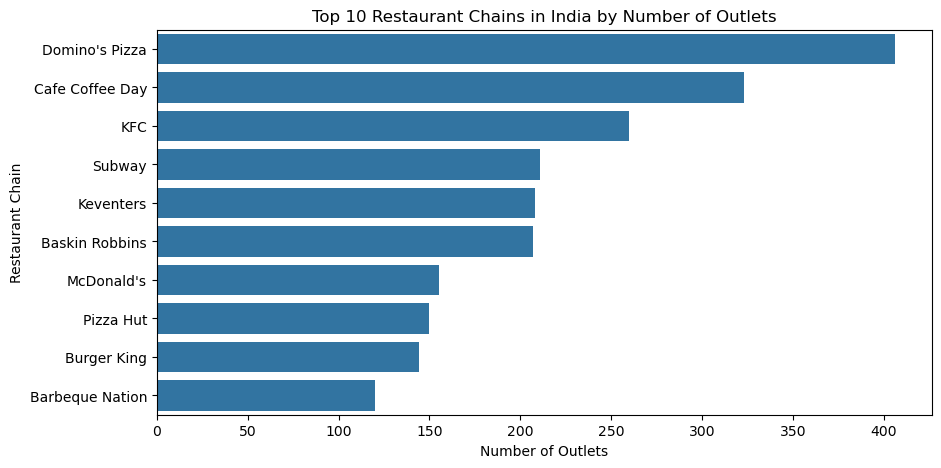

In [16]:
top_chains = df_clean['name'].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_chains.values, y=top_chains.index)
plt.title("Top 10 Restaurant Chains in India by Number of Outlets")
plt.xlabel("Number of Outlets")
plt.ylabel("Restaurant Chain")
plt.show()

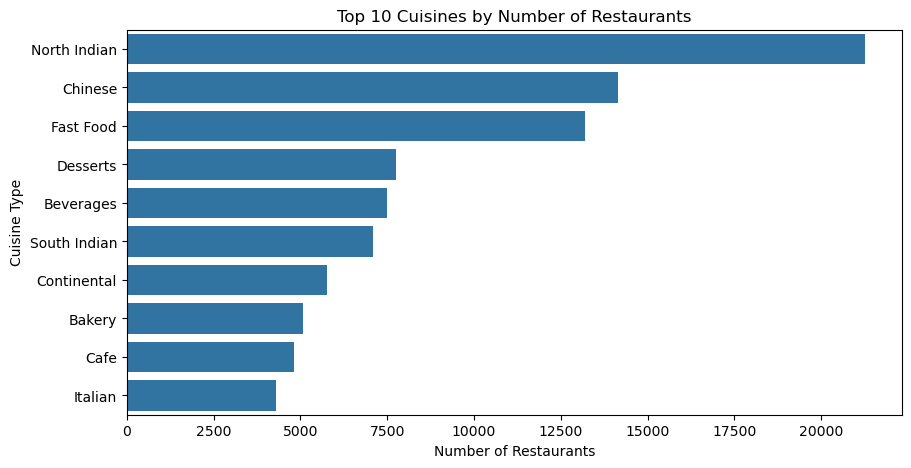

In [45]:
# Number of restaurants by cuisine type
df_clean['cuisines_split'] = df_clean['cuisines'].str.split(', ')
cuisine_counts = pd.Series(
    [cuisine for sublist in df_clean['cuisines_split'] for cuisine in sublist]
).value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=cuisine_counts.head(10).values, y=cuisine_counts.head(10).index)
plt.title("Top 10 Cuisines by Number of Restaurants")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine Type")
plt.show()

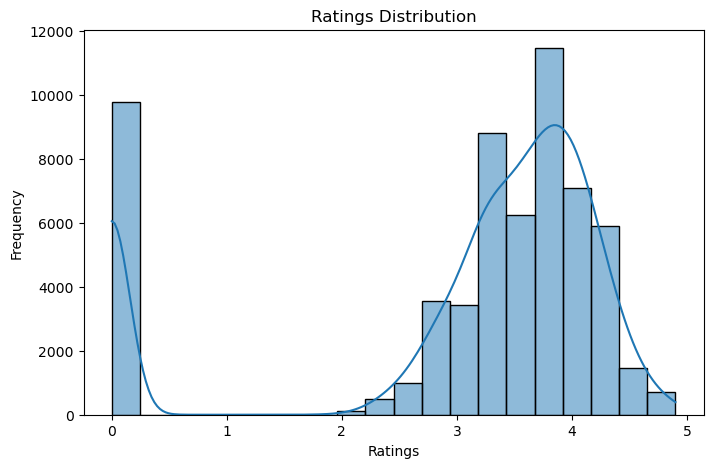

In [18]:
# Ratings distribution
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['aggregate_rating'], bins=20, kde=True)
plt.title("Ratings Distribution")
plt.xlabel("Ratings")
plt.ylabel("Frequency")
plt.show()

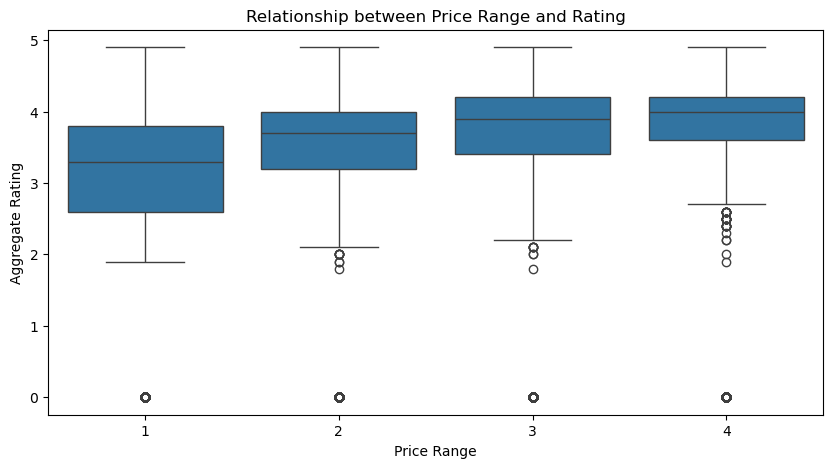

In [20]:
# Relationship between price range and rating
plt.figure(figsize=(10, 5))
sns.boxplot(x='price_range', y='aggregate_rating', data=df_clean)
plt.title("Relationship between Price Range and Rating")
plt.xlabel("Price Range")
plt.ylabel("Aggregate Rating")
plt.show()

/var/folders/__/yfxhqrzd2z949577b8zj_v9c0000gn/T/ipykernel_20555/1522519857.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_localities.values, y=top_localities.index, palette='magma')


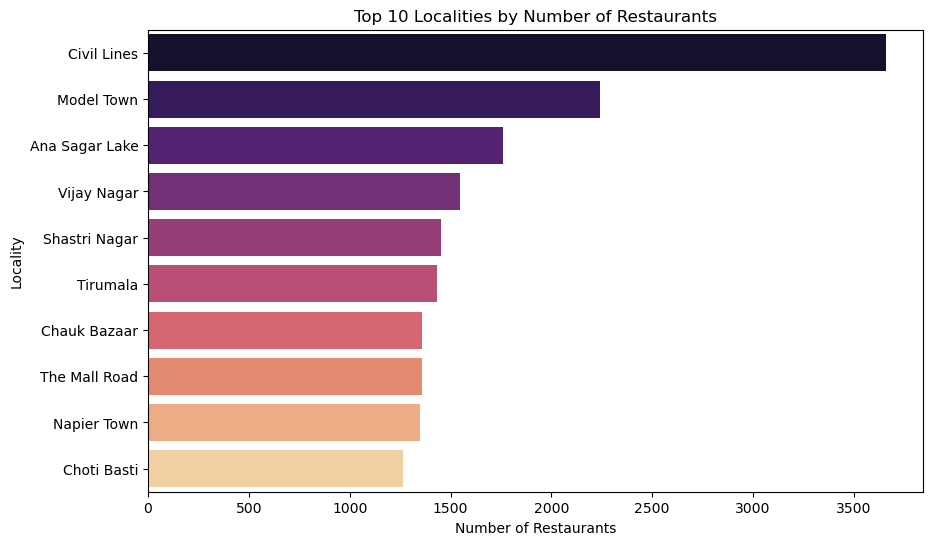

In [24]:
#Top 10 Localities with Most Restaurants

top_localities = df['locality'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_localities.values, y=top_localities.index, palette='magma')
plt.xlabel('Number of Restaurants')
plt.ylabel('Locality')
plt.title('Top 10 Localities by Number of Restaurants')
plt.show()

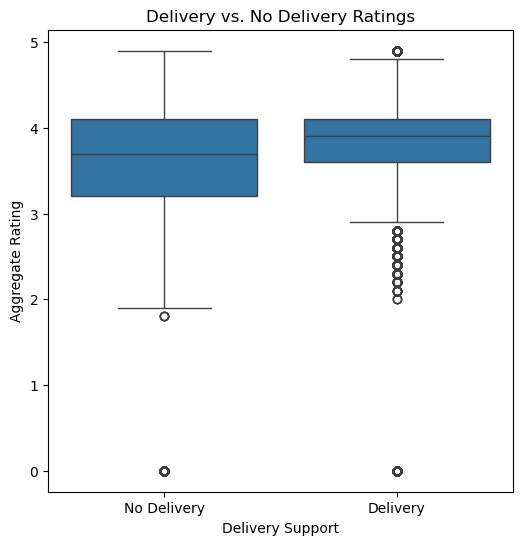

In [26]:
#Delivery vs No Delivery: Average Ratings

df['delivery'] = df['delivery'].replace(-1, 0)  # Ensure -1 treated as No Delivery

plt.figure(figsize=(6,6))
sns.boxplot(x='delivery', y='aggregate_rating', data=df)
plt.xticks([0,1], ['No Delivery', 'Delivery'])
plt.xlabel('Delivery Support')
plt.ylabel('Aggregate Rating')
plt.title('Delivery vs. No Delivery Ratings')
plt.show()


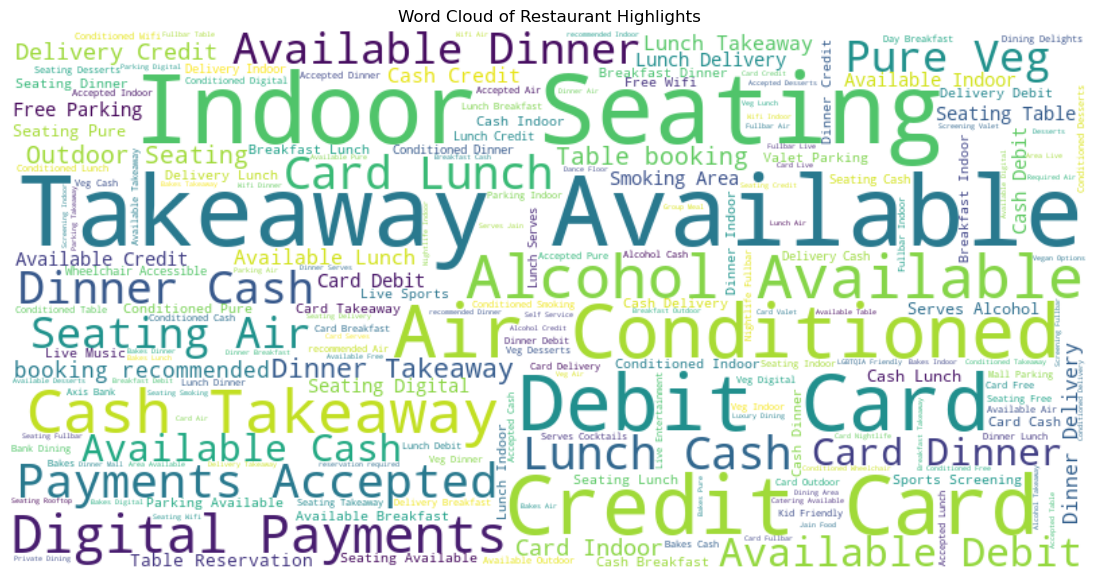

In [28]:
#Word CLoud of highlights

from wordcloud import WordCloud
import matplotlib.pyplot as plt
import ast

# Flatten all highlights into a single string
highlights_series = df['highlights'].dropna().apply(ast.literal_eval)
all_highlights = [item for sublist in highlights_series for item in sublist]
text = ' '.join(all_highlights)

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Restaurant Highlights')
plt.show()


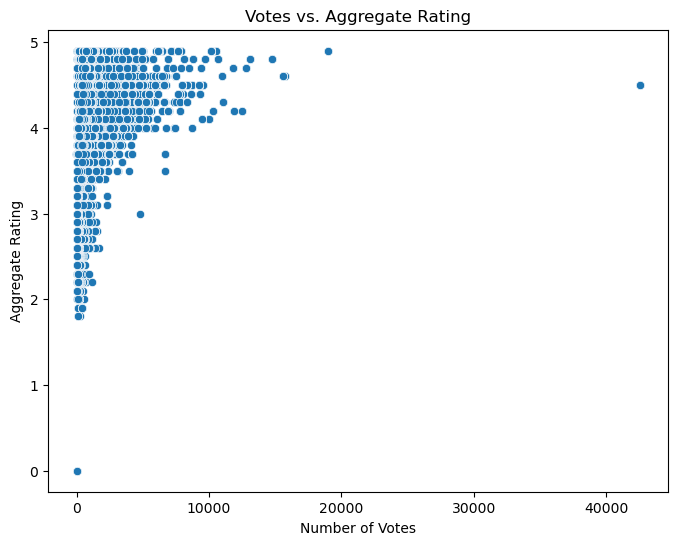

In [30]:
#Votes vs. Ratings Scatter Plot

plt.figure(figsize=(8,6))
sns.scatterplot(x='votes', y='aggregate_rating', data=df)
plt.xlabel('Number of Votes')
plt.ylabel('Aggregate Rating')
plt.title('Votes vs. Aggregate Rating')
plt.show()


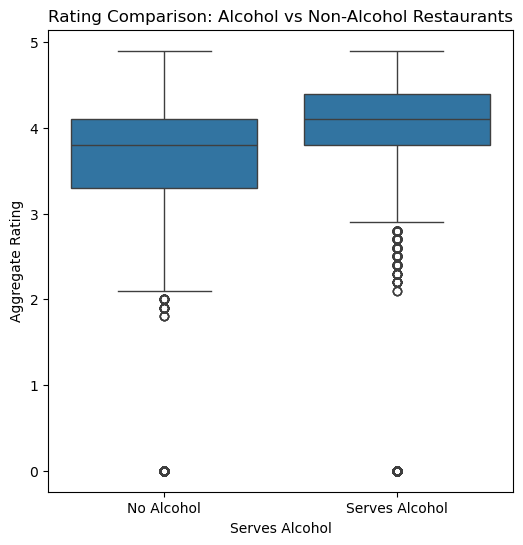

In [32]:
#Alcohol Serving Restaurants Ratings

df['serves_alcohol'] = df['highlights'].apply(lambda x: 'Serves Alcohol' in str(x))

plt.figure(figsize=(6,6))
sns.boxplot(x='serves_alcohol', y='aggregate_rating', data=df)
plt.xticks([0, 1], ['No Alcohol', 'Serves Alcohol'])
plt.xlabel('Serves Alcohol')
plt.ylabel('Aggregate Rating')
plt.title('Rating Comparison: Alcohol vs Non-Alcohol Restaurants')
plt.show()


In [38]:
pip install folium


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.4/113.4 kB 3.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [44]:


#Geospatial Plot of Restaurant Locations

import folium
from IPython.display import display

# Center map around Agra
map_agra = folium.Map(location=[27.1767, 78.0081], zoom_start=12)

# Plot top 50 rated restaurants
top_50 = df.sort_values(by='aggregate_rating', ascending=False).head(50)

for _, row in top_50.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        popup=f"{row['name']} ({row['aggregate_rating']})",
        color='blue',
        fill=True
    ).add_to(map_agra)

# Display the map directly in notebook
display(map_agra)



/var/folders/__/yfxhqrzd2z949577b8zj_v9c0000gn/T/ipykernel_20555/295381230.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=opentable_counts.index, y=opentable_counts.values, palette='coolwarm')


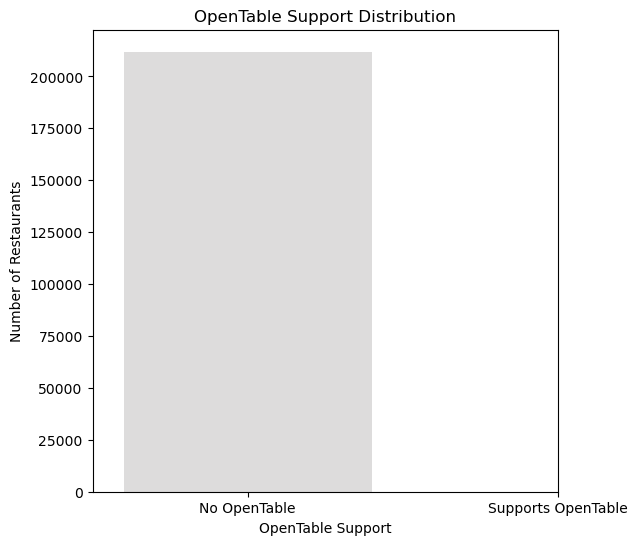

In [48]:
#OpenTable Support Count

opentable_counts = df['opentable_support'].replace(-1, 0).value_counts()

plt.figure(figsize=(6,6))
sns.barplot(x=opentable_counts.index, y=opentable_counts.values, palette='coolwarm')
plt.xticks([0,1], ['No OpenTable', 'Supports OpenTable'])
plt.xlabel('OpenTable Support')
plt.ylabel('Number of Restaurants')
plt.title('OpenTable Support Distribution')
plt.show()


In [52]:
# Summary of Insights from Zomato Restaurant Data Analysis

1. **Top Restaurant Chains**
   - The most widespread restaurant chains (like *Haldiram's, *Domino’s) dominate in outlet count, indicating strong brand presence and market reach across India.

2. **Popular Cuisines**
   - The majority of restaurants offer *North Indian*, *Chinese*, and *Fast Food* cuisines, reflecting the dominant food preferences of customers in India.

3. **Ratings Distribution**
   - Ratings are mostly concentrated between **3.5 to 4.5**, showing moderate to high customer satisfaction, with few restaurants having very low or perfect ratings.
   - Indicates general consistency in restaurant quality.

4. **Price vs. Ratings Relationship**
   - Mid-range restaurants tend to have a slightly higher average rating than low or high-priced ones.
   - Suggests that customers may find the best value-for-money at mid-tier pricing.

5. **Top Localities for Restaurants**
   - Areas like *Connaught Place* and *Andheri West* host the largest number of restaurants.
   - These localities are likely commercial or high foot-traffic zones, making them strategic locations for restaurant businesses.

6. **Impact of Delivery on Ratings**
   - Restaurants offering delivery services generally have **slightly higher average ratings** than those that don’t.
   - Indicates that convenient service boosts customer satisfaction.

7. **Word Cloud of Highlights**
   - Common features include *Credit Card Acceptance*, *Takeaway Available*, and *No Alcohol Served*.
   - These features are key selling points and should be considered when positioning restaurant services.

8. **Votes vs. Ratings Analysis**
   - No clear linear relationship: Some restaurants with many votes have moderate ratings.
   - Suggests that high visibility doesn’t always equate to high quality.

9. **Alcohol Serving Impact**
   - Restaurants serving alcohol show **higher average ratings** compared to those that don’t.
   - May indicate that customers perceive alcohol-serving restaurants as more upscale or complete dining experiences.


SyntaxError: unterminated string literal (detected at line 4) (254826327.py, line 4)